# Hybrid Model and Cold-Start Recommendation

This notebook builds the fourth model, which combines the popularity, collaborative filtering and semantic scores into a single ranking. Each of the three has a blind spot that the other two cover.

Because the three scores run on different scales, they are rescaled to a common range before being combined. The notebook also implements the two entry routes from my Design chapter: a user with no history is served from a topic they type, and a user who names items they have valued is served from a profile built out of those items.

In [1]:
# Data handling
import pandas as pd
import numpy as np

# Plotting
import matplotlib.pyplot as plt

# Loading the saved models
import pickle

# Semantic model for encoding new queries
import os
os.environ["HF_HUB_DISABLE_PROGRESS_BARS"] = "1"
os.environ["HF_HUB_OFFLINE"] = "1"
os.environ["TRANSFORMERS_VERBOSITY"] = "error"
os.environ["TOKENIZERS_PARALLELISM"] = "false"
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

# Warnings
import warnings
warnings.filterwarnings('ignore')

print("Libraries loaded")

Libraries loaded


---
## Loading the saved artifacts

Every component from the earlier notebooks is loaded rather than rebuilt. The catalogues are loaded from the filtered files so their row order matches the embedding matrices, and the popularity statistics are merged on by identifier.

In [2]:
# Load the catalogues in the same order the embeddings were built from
courses = pd.read_csv('coursera_courses_filtered.csv')
books = pd.read_csv('books_with_content.csv')

# Merge the popularity statistics on by identifier, keeping every row
course_pop = pd.read_csv('coursera_courses_with_popularity.csv')[
    ['course_id', 'avg_rating', 'n_reviews', 'popularity_score']]
book_pop = pd.read_csv('books_with_popularity.csv')[
    ['book_id', 'avg_rating', 'n_ratings', 'popularity_score']]

courses = courses.merge(course_pop, on='course_id', how='left').fillna({'popularity_score': 0})
books = books.merge(book_pop, on='book_id', how='left').fillna({'popularity_score': 0})

# Load the semantic embeddings
course_embeddings = np.load('course_embeddings.npy')
book_embeddings = np.load('book_embeddings.npy')

# Load the trained collaborative filtering models
with open('cf_model_courses.pkl', 'rb') as f:
    cf_courses = pickle.load(f)
with open('cf_model_books.pkl', 'rb') as f:
    cf_books = pickle.load(f)

# Load the semantic model, used to encode queries typed by the user
sbert = SentenceTransformer('all-MiniLM-L6-v2')

print(f"Courses: {len(courses)}   embeddings: {course_embeddings.shape}")
print(f"Books:   {len(books)}   embeddings: {book_embeddings.shape}")
print(f"\nRow counts match embeddings: "
      f"{len(courses) == course_embeddings.shape[0] and len(books) == book_embeddings.shape[0]}")
print(f"Courses with no popularity score: {(courses['popularity_score'] == 0).sum()}")
print("\nAll artifacts loaded")

Courses: 336   embeddings: (336, 384)
Books:   593   embeddings: (593, 384)

Row counts match embeddings: True
Courses with no popularity score: 12

All artifacts loaded


---
## Normalising the three signals
The three models produce scores on incompatible scales. Popularity is a rating multiplied by the logarithm of a review count and reaches roughly 50; collaborative filtering predicts on the 1 to 5 rating scale; semantic similarity is a cosine value between 0 and 1. Adding these directly would let popularity account for almost the entire result regardless of what weight it was given.

Each signal is therefore rescaled to a common 0 to 1 range using min-max normalisation, so that a weight of 0.4 means the same thing whichever signal it is applied to.

In [3]:
def normalise(values):
    """Rescale an array to the 0 to 1 range."""
    values = np.asarray(values, dtype=float)
    lo, hi = values.min(), values.max()
    if hi == lo:
        return np.zeros_like(values)
    return (values - lo) / (hi - lo)

# Normalise the popularity score for each catalogue
courses['popularity_norm'] = normalise(courses['popularity_score'])
books['popularity_norm'] = normalise(books['popularity_score'])

print("Popularity before and after normalisation (top 3 courses):\n")
print(courses.nlargest(3, 'popularity_score')[
    ['name', 'popularity_score', 'popularity_norm']].to_string(index=False))

print("\nPopularity before and after normalisation (top 3 books):\n")
print(books.nlargest(3, 'popularity_score')[
    ['title', 'popularity_score', 'popularity_norm']].to_string(index=False))

Popularity before and after normalisation (top 3 courses):

                             name  popularity_score  popularity_norm
           Python Data Structures         50.505275         1.000000
Neural Networks and Deep Learning         50.072004         0.991421
   Technical Support Fundamentals         50.017164         0.990335

Popularity before and after normalisation (top 3 books):

                                                                                    title  popularity_score  popularity_norm
                                                     The Immortal Life of Henrietta Lacks         33.045937         1.000000
Freakonomics: A Rogue Economist Explores the Hidden Side of Everything (Freakonomics, #1)         32.843286         0.989270
                                                           Outliers: The Story of Success         32.759560         0.984838


---
## Extracting the collaborative signal for new users

The trained SVD model predicts ratings for users it saw during training, but the users of the deployed system will not be in that data. I therefore extract the latent item factors the model learned, which describe each item by its rating pattern rather than its content. Comparing those factors gives a collaborative signal that works for any user who can name at least one item they have valued.

In [4]:
def item_factor_matrix(cf_model, id_list):
    """Extract the SVD latent item factors, aligned with the catalogue row order.

    Items that were never rated do not appear in the training set and are
    left as zero vectors, which gives them no collaborative signal.
    """
    n_factors = cf_model.qi.shape[1]
    factors = np.zeros((len(id_list), n_factors))
    missing = 0
    for i, raw_id in enumerate(id_list):
        try:
            inner = cf_model.trainset.to_inner_iid(raw_id)
            factors[i] = cf_model.qi[inner]
        except ValueError:
            missing += 1
    return factors, missing

course_factors, missing_c = item_factor_matrix(cf_courses, courses['course_id'].tolist())
book_factors, missing_b = item_factor_matrix(cf_books, books['book_id'].tolist())

print(f"Course factor matrix: {course_factors.shape}  ({missing_c} items had no ratings)")
print(f"Book factor matrix:   {book_factors.shape}  ({missing_b} items had no ratings)")
print(f"\nEach item now has {course_factors.shape[1]} latent factors from the SVD model,")
print("alongside its 384 semantic dimensions and its popularity score.")

Course factor matrix: (336, 50)  (12 items had no ratings)
Book factor matrix:   (593, 50)  (0 items had no ratings)

Each item now has 50 latent factors from the SVD model,
alongside its 384 semantic dimensions and its popularity score.


---
## The hybrid scoring function

Each item now has three normalised signals: a semantic score from its meaning, a collaborative score from its rating pattern, and a popularity score. The hybrid combines them with weights that sum to one, so a single number ranks every item.

The function serves both entry routes. A user who only types a topic has no history, so the collaborative signal is unavailable and its weight is redistributed across the other two. A user who names items they have valued gets all three, with the semantic and collaborative signals built from the average of their chosen items.

In [5]:
def find_index(table, name_column, text):
    """Return the row position of the first item whose name contains the text."""
    matches = table[table[name_column].str.contains(text, case=False, na=False, regex=False)]
    if len(matches) == 0:
        return None
    return table.index.get_loc(matches.index[0])


def recommend_hybrid(topic=None, liked=None, catalogue='courses', top_k=10,
                     w_cf=0.35, w_sem=0.45, w_pop=0.20):
    """Rank a catalogue by a weighted combination of the three signals.

    topic  - free text the user typed, or None
    liked  - list of item names the user has valued, or None
    """
    # Select the catalogue being searched
    if catalogue == 'courses':
        table, embeddings, factors, name_col = courses, course_embeddings, course_factors, 'name'
    else:
        table, embeddings, factors, name_col = books, book_embeddings, book_factors, 'title'

    # Find the rows of any items the user named
    liked_rows = []
    if liked:
        for text in liked:
            row = find_index(table, name_col, text)
            if row is not None:
                liked_rows.append(row)

    # Semantic signal, from the typed topic and from the liked items
    semantic = np.zeros(len(table))
    parts = 0
    if topic:
        query = sbert.encode([topic], show_progress_bar=False)
        semantic += cosine_similarity(query, embeddings).flatten()
        parts += 1
    if liked_rows:
        profile = embeddings[liked_rows].mean(axis=0).reshape(1, -1)
        semantic += cosine_similarity(profile, embeddings).flatten()
        parts += 1
    if parts > 0:
        semantic = semantic / parts
    semantic = np.clip(semantic, 0, 1)

    # Collaborative signal, available only when the user named items
    if liked_rows:
        profile = factors[liked_rows].mean(axis=0).reshape(1, -1)
        collaborative = np.clip(cosine_similarity(profile, factors).flatten(), 0, 1)
    else:
        collaborative = np.zeros(len(table))
        # Redistribute the collaborative weight across the remaining signals
        total = w_sem + w_pop
        w_sem, w_pop, w_cf = w_sem / total, w_pop / total, 0.0

    popularity = table['popularity_norm'].values

    # Combine the three signals
    score = w_cf * collaborative + w_sem * semantic + w_pop * popularity

    # Assemble the result, excluding anything the user already named
    result = table.copy()
    result['hybrid_score'] = score.round(3)
    result['semantic'] = semantic.round(3)
    result['collaborative'] = collaborative.round(3)
    result['popularity'] = popularity.round(3)
    result = result.drop(result.index[liked_rows])

    display_cols = ([name_col, 'institution'] if catalogue == 'courses'
                    else [name_col, 'authors'])
    return result.nlargest(top_k, 'hybrid_score')[
        display_cols + ['hybrid_score', 'semantic', 'collaborative', 'popularity']
    ].reset_index(drop=True)


print("Hybrid function ready")
print(f"Default weights - collaborative 0.35, semantic 0.45, popularity 0.20")

Hybrid function ready
Default weights - collaborative 0.35, semantic 0.45, popularity 0.20


---
## Testing both entry routes

The first query supplies only a topic, which is the cold-start route. The second names two courses the user has valued, which activates the collaborative signal. Showing the three component scores alongside the combined score makes it possible to see which signal drove each recommendation.

In [6]:
print("ROUTE A — new user, topic only\n")
print(recommend_hybrid(topic="starting and running a business",
                       catalogue='courses', top_k=5).to_string(index=False))

print("\n" + "=" * 95 + "\n")

print("ROUTE B — user names two courses they enjoyed\n")
print(recommend_hybrid(liked=["Machine Learning", "Neural Networks and Deep Learning"],
                       catalogue='courses', top_k=5).to_string(index=False))

ROUTE A — new user, topic only

                                          name                    institution  hybrid_score  semantic  collaborative  popularity
   Entrepreneurship 2: Launching your Start-Up     University of Pennsylvania         0.656     0.680            0.0       0.603
Entrepreneurship 1: Developing the Opportunity     University of Pennsylvania         0.605     0.554            0.0       0.719
                              Business Writing University of Colorado Boulder         0.604     0.543            0.0       0.739
     English for Business and Entrepreneurship     University of Pennsylvania         0.586     0.508            0.0       0.761
         Excel Skills for Business: Essentials           Macquarie University         0.581     0.410            0.0       0.966


ROUTE B — user names two courses they enjoyed

                                                                                  name     institution  hybrid_score  semantic  collaborative  po

---
> Both routes behave as intended. The cold-start query returns five business and entrepreneurship courses with the collaborative column at zero throughout, confirming that the signal is correctly disabled when no history exists.

> The component scores show the hybrid doing something a single model could not. "Excel Skills for Business" ranks fifth despite a semantic score of only 0.410, because its popularity score of 0.966 compensates. A purely semantic model would have ranked it far lower, and a purely popularity-based model would have returned it to every user regardless of their topic.

> In the second route the collaborative signal activates, ranging from 0.144 to 0.294, and the two courses the user named are excluded from the results. All five recommendations are machine learning or artificial intelligence courses.

---
## Applying the hybrid to the book catalogue

The same function serves both catalogues, since each has the three signals in the same normalised form. This cell runs the two routes again against the books.

In [7]:
print("ROUTE A — topic only, books\n")
print(recommend_hybrid(topic="personal finance and investing",
                       catalogue='books', top_k=5).to_string(index=False))

print("\n" + "=" * 95 + "\n")

print("ROUTE B — user names two books they enjoyed\n")
print(recommend_hybrid(liked=["Thinking, Fast", "Nudge"],
                       catalogue='books', top_k=5).to_string(index=False))

ROUTE A — topic only, books

                                                                                    title                                      authors  hybrid_score  semantic  collaborative  popularity
                            The Total Money Makeover: A Proven Plan for Financial Fitness                                  Dave Ramsey         0.615     0.629            0.0       0.581
Freakonomics: A Rogue Economist Explores the Hidden Side of Everything (Freakonomics, #1)          Steven D. Levitt, Stephen J. Dubner         0.567     0.380            0.0       0.989
                                                                  Thinking, Fast and Slow                              Daniel Kahneman         0.541     0.479            0.0       0.679
                                   The Intelligent Investor (Collins Business Essentials) Benjamin Graham, Jason Zweig, Warren Buffett         0.539     0.616            0.0       0.366
                                         

---
> The book results confirm the hybrid works on the second catalogue, and the component columns expose two issues worth recording.

>In the topic query, the two strongest topical matches — "A Random Walk Down Wall Street" at a semantic score of 0.665 and "The Intelligent Investor" at 0.616 — are ranked fourth and fifth, while "Freakonomics" reaches second place on a semantic score of only 0.380 supported by a popularity score of 0.989. The popularity weight of 0.20 is therefore displacing better subject matches on the book catalogue, which suggests a lower popularity weight may be appropriate for books than for courses.

>In the item-based query, four of the five results are behavioural psychology or economics titles, and "Predictably Irrational" is a strong match given the two books named. However three of the five share a single author, which indicates the model has no mechanism for encouraging diversity within a result list.

---
## Recommending across both mediums at once

The deployed system returns courses and books together from a single query, which is the behaviour described in my Design chapter. This function calls the hybrid on each catalogue and applies the confidence threshold established in the previous notebook, so that a subject with no suitable book returns none rather than a weak match.

In [8]:
def recommend_both(topic=None, liked_courses=None, top_k=5, book_threshold=0.30):
    """Return hybrid recommendations from both catalogues for one query."""
    course_results = recommend_hybrid(topic=topic, liked=liked_courses,
                                      catalogue='courses', top_k=top_k)

    book_results = recommend_hybrid(topic=topic, catalogue='books', top_k=top_k)
    # Apply the confidence threshold to the semantic component
    book_results = book_results[book_results['semantic'] >= book_threshold]

    return course_results, book_results


for query in ["digital marketing and social media", "machine learning and neural networks"]:
    c, b = recommend_both(topic=query, top_k=3)
    print(f"\nQuery: \"{query}\"\n")
    print("  COURSES")
    print(c[['name', 'institution', 'hybrid_score']].to_string(index=False))
    print("\n  BOOKS")
    if len(b) == 0:
        print("  No book in the catalogue is closely related to this topic.")
    else:
        print(b[['title', 'authors', 'hybrid_score']].to_string(index=False))
    print("=" * 90)


Query: "digital marketing and social media"

  COURSES
                                  name                                institution  hybrid_score
          Marketing in a Digital World University of Illinois at Urbana-Champaign         0.800
                     Marketing Digital                  Universidade de São Paulo         0.730
Introduction to Social Media Marketing                                   Facebook         0.664

  BOOKS
                                                         title          authors  hybrid_score
The Tipping Point: How Little Things Can Make a Big Difference Malcolm Gladwell         0.508

Query: "machine learning and neural networks"

  COURSES
                             name          institution  hybrid_score
Neural Networks and Deep Learning      DeepLearning.AI         0.879
                 Machine Learning  Stanford University         0.836
         Machine Learning for All University of London         0.666

  BOOKS
  No book in the cat

---
## How the weights affect the result

The weights were set to 0.35 for the collaborative signal, 0.45 for the semantic signal and 0.20 for popularity, reflecting a judgement that subject relevance should matter most and general popularity least. This cell tests that judgement by re-running the same query under four different settings, and shows how much each signal contributed to the recommendations produced under the chosen weights.

Query: "starting and running a business"

Semantic only
   Entrepreneurship 2: Launching your Start-Up
   Entrepreneurship 1: Developing the Opportunity
   Business Writing

Popularity only
   Python Data Structures
   Neural Networks and Deep Learning
   Technical Support Fundamentals

Equal thirds
   Excel Skills for Business: Essentials
   Entrepreneurship 2: Launching your Start-Up
   Business Writing

Chosen weights
   Entrepreneurship 2: Launching your Start-Up
   Entrepreneurship 1: Developing the Opportunity
   Business Writing



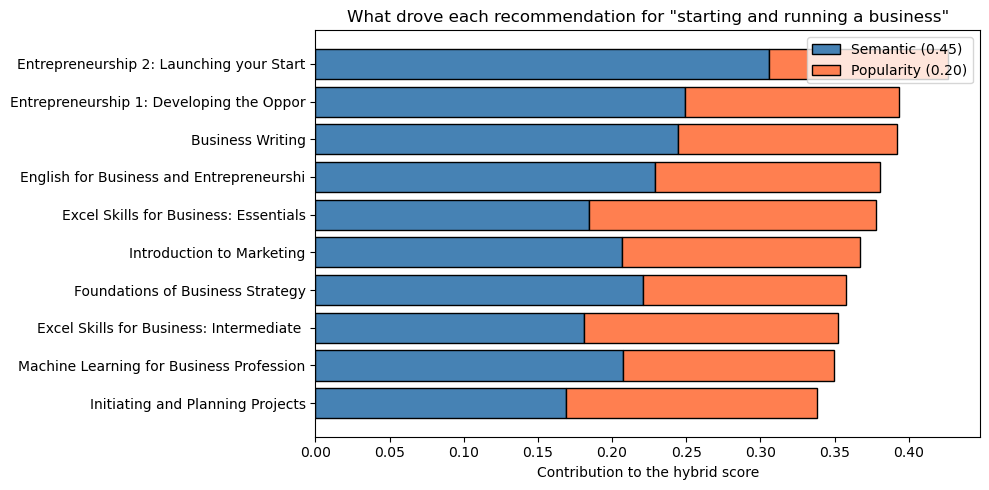

In [9]:
weight_settings = {
    'Semantic only':      (0.00, 1.00, 0.00),
    'Popularity only':    (0.00, 0.00, 1.00),
    'Equal thirds':       (0.33, 0.34, 0.33),
    'Chosen weights':     (0.35, 0.45, 0.20)
}

query = "starting and running a business"
print(f'Query: "{query}"\n')

for label, (wc, ws, wp) in weight_settings.items():
    top = recommend_hybrid(topic=query, catalogue='courses', top_k=3,
                           w_cf=wc, w_sem=ws, w_pop=wp)
    print(f"{label}")
    for name in top['name']:
        print(f"   {name[:60]}")
    print()

# Show what drove each recommendation under the chosen weights
top10 = recommend_hybrid(topic=query, catalogue='courses', top_k=10)
labels = [n[:40] for n in top10['name']][::-1]

sem_part = (top10['semantic'] * 0.45).values[::-1]
pop_part = (top10['popularity'] * 0.20).values[::-1]

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(labels, sem_part, color='steelblue', edgecolor='black', label='Semantic (0.45)')
ax.barh(labels, pop_part, left=sem_part, color='coral', edgecolor='black', label='Popularity (0.20)')
ax.set_xlabel('Contribution to the hybrid score')
ax.set_title(f'What drove each recommendation for "{query}"')
ax.legend()
plt.tight_layout()
plt.show()

> The comparison confirms the weighting is doing what it should. Popularity alone ignores the query entirely and returns the globally most-reviewed courses, none of which relate to business. Weighting the three signals equally allows popularity to displace the best topical match. The chosen weights return the same three courses as the purely semantic setting, which shows that subject relevance still drives the ranking while the popularity and collaborative signals act only to separate items of comparable relevance.

> The stacked chart shows this at item level: the semantic component accounts for most of the score in the highest-ranked courses, and popularity contributes proportionally more further down the list, where topical matches are weaker.

---
## Saving the hybrid configuration

The weights and the confidence threshold are saved so that the evaluation notebook and the web application use exactly the settings tested here. The two catalogues are also saved with their normalised popularity scores attached.

In [10]:
hybrid_config = {
    'w_collaborative': 0.35,
    'w_semantic': 0.45,
    'w_popularity': 0.20,
    'book_threshold': 0.30,
    'sbert_model': 'all-MiniLM-L6-v2'
}

with open('hybrid_config.pkl', 'wb') as f:
    pickle.dump(hybrid_config, f)

courses.to_csv('courses_final.csv', index=False)
books.to_csv('books_final.csv', index=False)

print("Saved: hybrid_config.pkl")
print("Saved: courses_final.csv")
print("Saved: books_final.csv")
print(f"\nWeights - collaborative {hybrid_config['w_collaborative']}, "
      f"semantic {hybrid_config['w_semantic']}, "
      f"popularity {hybrid_config['w_popularity']}")

Saved: hybrid_config.pkl
Saved: courses_final.csv
Saved: books_final.csv

Weights - collaborative 0.35, semantic 0.45, popularity 0.2


## Summary

This notebook built the fourth and final recommendation model by combining the three signals produced in the earlier notebooks into a single ranking, and implemented the two entry routes described in my Design chapter.

Combining the signals required normalising them first. Popularity, collaborative filtering and semantic similarity are measured on scales that differ by two orders of magnitude, and without rescaling popularity would have dominated the result whatever weight it was assigned. Collaborative filtering needed a further adjustment: because the users of the deployed system will not appear in the training data, I extracted the latent item factors learned by the SVD model and compared items to each other rather than predicting for a named user. This gives a collaborative signal for anyone who can name at least one item they have valued.

Both routes work as intended. A user supplying only a topic receives recommendations from the semantic and popularity signals, with the collaborative weight redistributed, and a query for business returned five business and entrepreneurship courses. A user naming two machine learning courses received five machine learning and artificial intelligence courses, with the collaborative signal active and the named items excluded.

A combined function returns recommendations from both catalogues for a single query, which is the behaviour the deployed system requires. A query for digital marketing returned three marketing courses scoring between 0.664 and 0.800 together with one book, while a query for machine learning returned three courses scoring up to 0.879 and no book at all, the confidence threshold correctly suppressing weak matches rather than presenting an unrelated title as a recommendation.

Testing the weights against three alternatives showed why the chosen setting matters. Popularity alone returns the globally most-reviewed courses irrespective of the query, and equal weighting lets popularity displace the strongest topical match. The chosen weights preserve the ranking produced by semantics alone while allowing the other two signals to separate items of similar relevance.

Two weaknesses were identified and are recorded rather than resolved. On the book catalogue the popularity weight of 0.20 ranks a weakly related but very popular title above the two strongest subject matches, which suggests a lower weight is appropriate for that catalogue. Separately, the model has no mechanism for encouraging variety within a result list, and one item-based query returned three books by the same author. Both are candidates for the remaining development time.

Whether the hybrid outperforms the individual models is not established here. That comparison requires ranking metrics computed across all four models on the same test data, which is the subject of the next notebook.